# 01 — Análise Exploratória de Dados

**Dimensão 3 da rúbrica — 20 pontos.**

Toda visualização precisa de um parágrafo de interpretação logo abaixo.
Gráfico sem leitura perde metade dos pontos do critério.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

RAW_CREDIT_RECORD= Path("..") / "data" / "raw" / "credit_record.csv"          # PREENCHER: nome do arquivo
RAW_APPLICATION_RECORD= Path("..") / "data" / "raw" / "application_record.csv"     # PREENCHER: nome do arquivo
PROCESSED = Path("..") / "data" / "processed"
TARGET = "target"                                            # PREENCHER: variável alvo

pd.set_option("display.max_columns", None)

/home/markosokada/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.9.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/markosokada/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Carregando as cópias das bases de dados originais
df_credit_record = pd.read_csv(RAW_CREDIT_RECORD)
df_application_record = pd.read_csv(RAW_APPLICATION_RECORD)

In [3]:
import dtale
import dtale.app as dtale_app

dtale_app.USE_COLAB = True
dtale.show(df_application_record)

In [4]:
dtale.show(df_credit_record)

## 1. Visão geral

_Dimensões, tipos e primeira impressão do dataset._

In [5]:
# Verificando as dimensões iniciais das bases
print("Dimensões de df_application_record:", df_application_record.shape)
print("Dimensões de df_credit_record:", df_credit_record.shape)

# Informações sobre tipos de dados e contagem de nulos
print("\n--- Informações Cadastrais (df_application_record) ---")
df_application_record.info()

print("\n--- Informações de Crédito Monthly (df_credit_record) ---")
df_credit_record.info()

# Estatísticas descritivas das variáveis numéricas originais
print("\n--- Estatísticas Cadastrais ---")
display(df_application_record.describe().T)

Dimensões de df_application_record: (438557, 18)
Dimensões de df_credit_record: (1048575, 3)

--- Informações Cadastrais (df_application_record) ---
<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  str    
 2   FLAG_OWN_CAR         438557 non-null  str    
 3   FLAG_OWN_REALTY      438557 non-null  str    
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  str    
 7   NAME_EDUCATION_TYPE  438557 non-null  str    
 8   NAME_FAMILY_STATUS   438557 non-null  str    
 9   NAME_HOUSING_TYPE    438557 non-null  str    
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-

,count,mean,std,min,25%,50%,75%,max
ID,438557.0,6.022176e+06,571637.023257,5008804.0,5609375.0,6047745.0,6456971.0,7999952.0
CNT_CHILDREN,438557.0,4.273903e-01,0.724882,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,438557.0,1.875243e+05,110086.853066,26100.0,121500.0,160780.5,225000.0,6750000.0
DAYS_BIRTH,438557.0,-1.599790e+04,4185.030007,-25201.0,-19483.0,-15630.0,-12514.0,-7489.0
DAYS_EMPLOYED,438557.0,6.056368e+04,138767.799647,-17531.0,-3103.0,-1467.0,-371.0,365243.0
FLAG_MOBIL,438557.0,1.000000e+00,0.000000,1.0,1.0,1.0,1.0,1.0
FLAG_WORK_PHONE,438557.0,2.061328e-01,0.404527,0.0,0.0,0.0,0.0,1.0
FLAG_PHONE,438557.0,2.877710e-01,0.452724,0.0,0.0,0.0,1.0,1.0
FLAG_EMAIL,438557.0,1.082071e-01,0.310642,0.0,0.0,0.0,0.0,1.0
CNT_FAM_MEMBERS,438557.0,2.194465e+00,0.897207,1.0,2.0,2.0,3.0,20.0


### Dicionário de Dados do df_application_record
|  **Nome da Coluna**      | Tipo de Dado | Descrição / Significado |  
| :---: | :---: | :---: |
| **ID**                  | int64   | dentificador único do cliente. |  
| **CODE_GENDER**         | object  | Gênero do cliente (Ex: M/F). |  
| **FLAG_OWN_CAR**        | object  | Indica se o cliente possui carro próprio (Y/N). |  
| **FLAG_OWN_REALTY**     | object  | Indica se o cliente possui imóvel próprio (Y/N). |  
| **CNT_CHILDREN**        | int64   | Quantidade de filhos do cliente. |  
| **AMT_INCOME_TOTAL**    | float64 | Rendimento anual total do cliente. |  
| **NAME_INCOME_TYPE**    | object  | Tipo de renda (Ex: Assalariado, Pensionista, Estudante). |  
| **NAME_EDUCATION_TYPE** | object  | Grau de escolaridade (Ex: Ensino Médio, Ensino Superior). |  
| **NAME_FAMILY_STATUS**  | object  | Estado civil (Ex: Casado, Solteiro, Divorciado). |  
| **NAME_HOUSING_TYPE**   | object  | Tipo de moradia (Ex: Casa própria, Apartamento alugado). |  
| **DAYS_BIRTH**          | int64   | Idade em dias (contados regressivamente a partir de hoje. Ex:  -12000). |  
| **DAYS_EMPLOYED**       | int64   | Tempo de emprego em dias (regressivo. Se positivo, significa desempregado). |  
| **FLAG_MOBIL**          | int64   | Indica se informou telefone celular (1 = Sim, 0 = Não). |  
| **FLAG_WORK_PHONE**     | int64   | Indica se informou telefone comercial (1 = Sim, 0 = Não). |  
| **FLAG_PHONE**          | int64   | Indica se informou telefone fixo residencial (1 = Sim, 0 = Não). |  
| **FLAG_EMAIL**          | int64   | Indica se informou e-mail (1 = Sim, 0 = Não). |  
| **OCCUPATION_TYPE**     | object  | Profissão/Ocupação (Contém dados faltantes). |  
| **CNT_FAM_MEMBERS**     | float64 | Quantidade de membros na família. |  

### Dicionário de Dados do df_credit_record
|  **Nome da Coluna**      | Tipo de Dado | Descrição / Significado |  
| :---: | :---: | :---: |
| **ID**                  | int64   | Identificador único do cliente ou da conta de crédito.5001711, 5001712| 
| **MONTHS_BALANCE**      | int64   | Mês de referência dos dados em relação ao mês atual.0 (mês atual), -1 (1 mês atrás), -2 (2 meses atrás)|
| **STATUS**              | object  | Situação de pagamento (0: 1-29 dias; 1: 30-59; 2: 60-89; 3: 90-119; 4: 120-149; 5: >150 dias; C: pago; X: sem empréstimo).|

## 2. Distribuição das variáveis

### Análise da Renda Anual Total (AMT_INCOME_TOTAL)

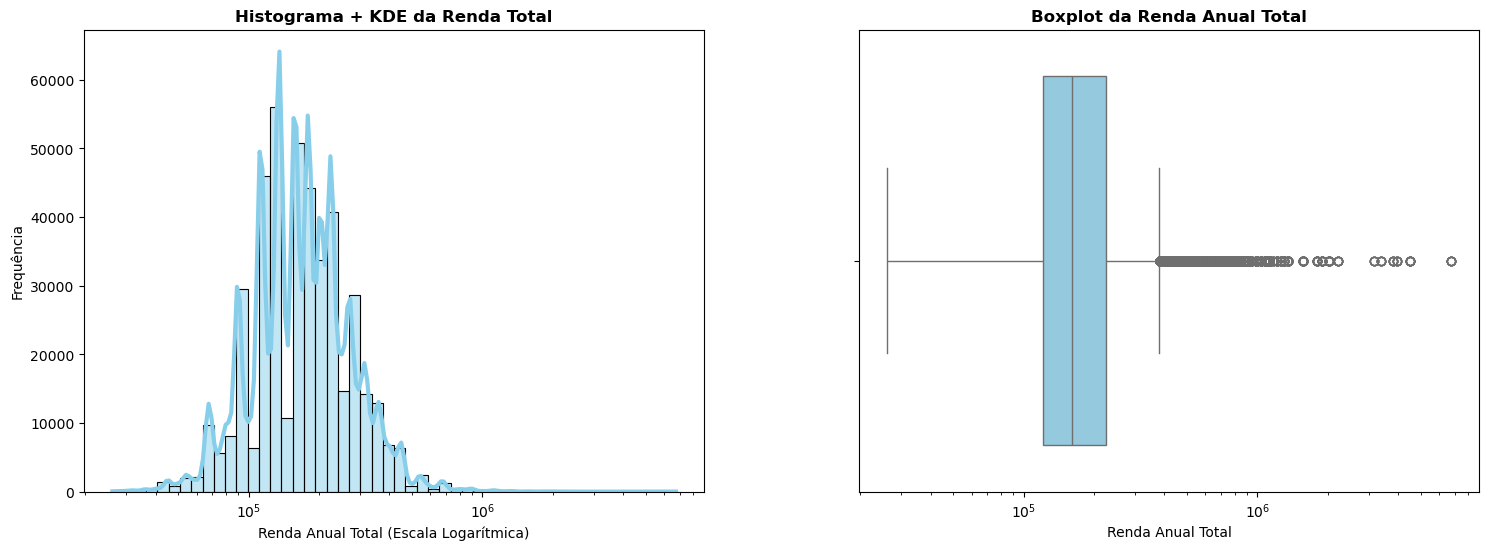

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.subplots_adjust(wspace=0.25)

# Gráfico 1: Histograma + KDE (Escala Logarítmica)
sns.histplot(
    data=df_application_record,
    x="AMT_INCOME_TOTAL",
    kde=True,
    color="skyblue",
    bins=50,
    log_scale=True,
    line_kws={'linewidth': 3, 'color': 'darkblue'},
    ax=axes[0]
)
axes[0].set_title("Histograma + KDE da Renda Total", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Renda Anual Total (Escala Logarítmica)")
axes[0].set_ylabel("Frequência")

# Gráfico 2: Boxplot (Escala Logarítmica)
sns.boxplot(
    data=df_application_record,
    x="AMT_INCOME_TOTAL",
    color="skyblue",
    ax=axes[1]
)
axes[1].set_title('Boxplot da Renda Anual Total', fontsize=12, fontweight='bold')
axes[1].set_xlabel("Renda Anual Total")
axes[1].set_xscale('log')

plt.show()

Perfil do Público Alvo: A base de clientes exibe uma forte concentração na classe 
média alta, com a mediana da renda anual situada próxima a 160.000 unidades 
monetárias. Sob a perspectiva estatística, a distribuição da renda apresenta uma 
assimetria acentuada à direita, mas assume um formato de sino simétrico e bem 
definido quando convertida para a escala logarítmica (Log-Normal). Isso indica 
que uma transformação matemática (como log1p) suavizará perfeitamente o impacto 
de outliers de alta renda (valores acima de 400.000), tornando-a altamente aderente 
para algoritmos preditivos baseados em distância ou modelos lineares.


### Análise da Idade dos Clientes (DAYS_BIRTH convertido para Idade)

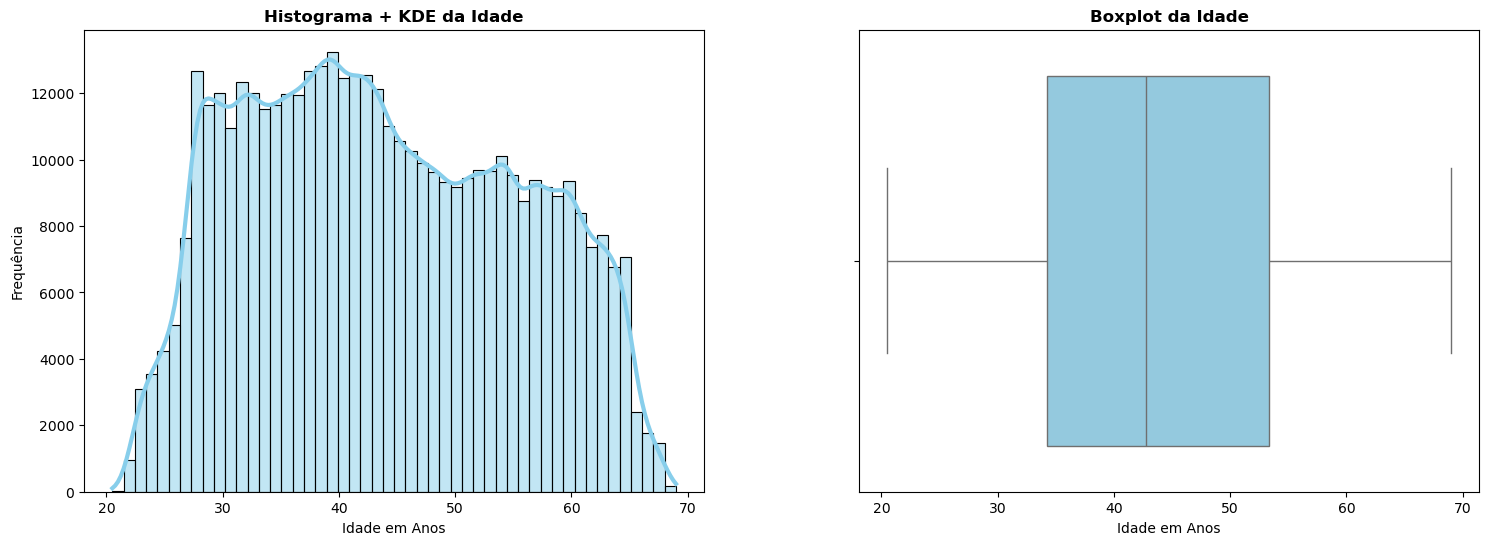

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.subplots_adjust(wspace=0.25)

# Conversão temporária de dias negativos para idade positiva em anos
idade_anos = -df_application_record['DAYS_BIRTH'] / 365.25

# Gráfico 1: Histograma + KDE
sns.histplot(
    x=idade_anos,
    kde=True,
    color="skyblue",
    bins=50,
    line_kws={'linewidth': 3, 'color': 'darkblue'},
    ax=axes[0]
)
axes[0].set_title("Histograma + KDE da Idade", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Idade em Anos")
axes[0].set_ylabel("Frequência")

# Gráfico 2: Boxplot
sns.boxplot(
    x=idade_anos,
    color="skyblue",
    ax=axes[1]
)
axes[1].set_title('Boxplot da Idade', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Idade em Anos')

plt.show()

Distribuição Etária Equilibrada: A análise da idade indica uma carteira de 
clientes madura e consolidada, com comportamento estatisticamente estável. A 
mediana etária é de 43 anos, e o grosso da população cadastrada (o intervalo 
interquartílico no Boxplot) distribui-se de maneira uniforme entre 34 e 53 anos. 
Trata-se de um público em plena fase de estabilidade financeira e atividade 
econômica ativa, o que reduz incertezas no perfil cadastral. Adicionalmente, 
a distribuição não apresenta assimetrias severas e está totalmente livre de 
outliers (anomalias), dispensando remoções ou tratamentos extremos nesta coluna.

### Análise do Tempo de Emprego (DAYS_EMPLOYED convertido para Anos)

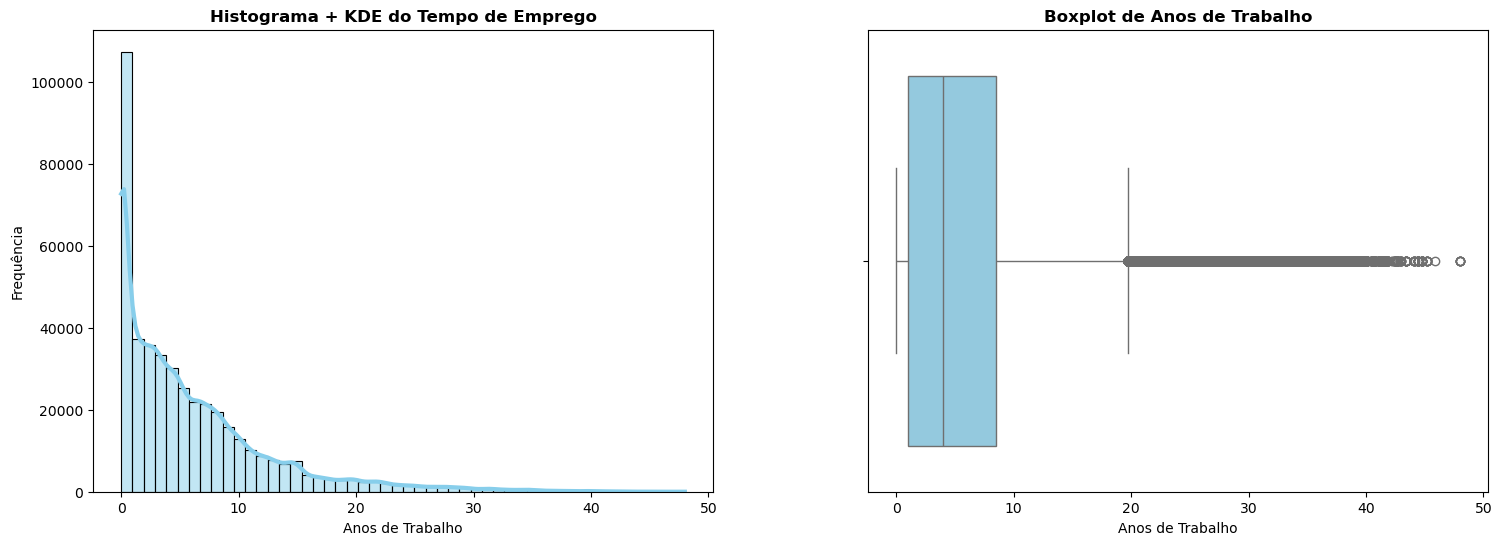

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.subplots_adjust(wspace=0.25)

# Tratamento temporário isolando o valor anômalo (365243) para cálculo real de anos
anos_trabalho = df_application_record["DAYS_EMPLOYED"].apply(lambda x: -x / 365.25 if x < 0 else 0)

# Gráfico 1: Histograma + KDE
sns.histplot(
    x=anos_trabalho,
    kde=True,
    color="skyblue",
    bins=50,
    line_kws={'linewidth': 3, 'color': 'darkblue'},
    ax=axes[0]
)
axes[0].set_title("Histograma + KDE do Tempo de Emprego", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Anos de Trabalho")
axes[0].set_ylabel("Frequência")

# Gráfico 2: Boxplot
sns.boxplot(
    x=anos_trabalho,
    color="skyblue",
    ax=axes[1]
)
axes[1].set_title('Boxplot de Anos de Trabalho', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Anos de Trabalho')

plt.show()


Dinâmica Profissional e Estabilidade: O tempo de serviço apresenta um pico 
expressivo na marca de 0 anos, impulsionado pela presença massiva do valor 
técnico original '365243', que representa indivíduos sem vínculo formal ativo 
(como aposentados e pensionistas). Entre a parcela economicamente activa, nota-se 
um perfil de transição ou menor estabilidade no emprego atual, visto que a 
maioria absoluta possui menos de 7 anos de casa. Contudo, o boxplot revela uma 
cauda longa com outliers legítimos de clientes que mantêm alta estabilidade corporativa 
(mais de 20 anos na mesma função), um fator altamente favorável à concessão de crédito.


### Análise da Estrutura Familiar (Filhos e Membros)

2026-08-30 22:42:21,030 - INFO     - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/tmp/ipykernel_44744/2140716384.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
2026-08-30 22:42:21,213 - INFO     - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-30 22:42:21,666 - INFO     - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/tmp/ipykernel_44744/2140716384.py:17: FutureWarning: 

Passing `palette` without

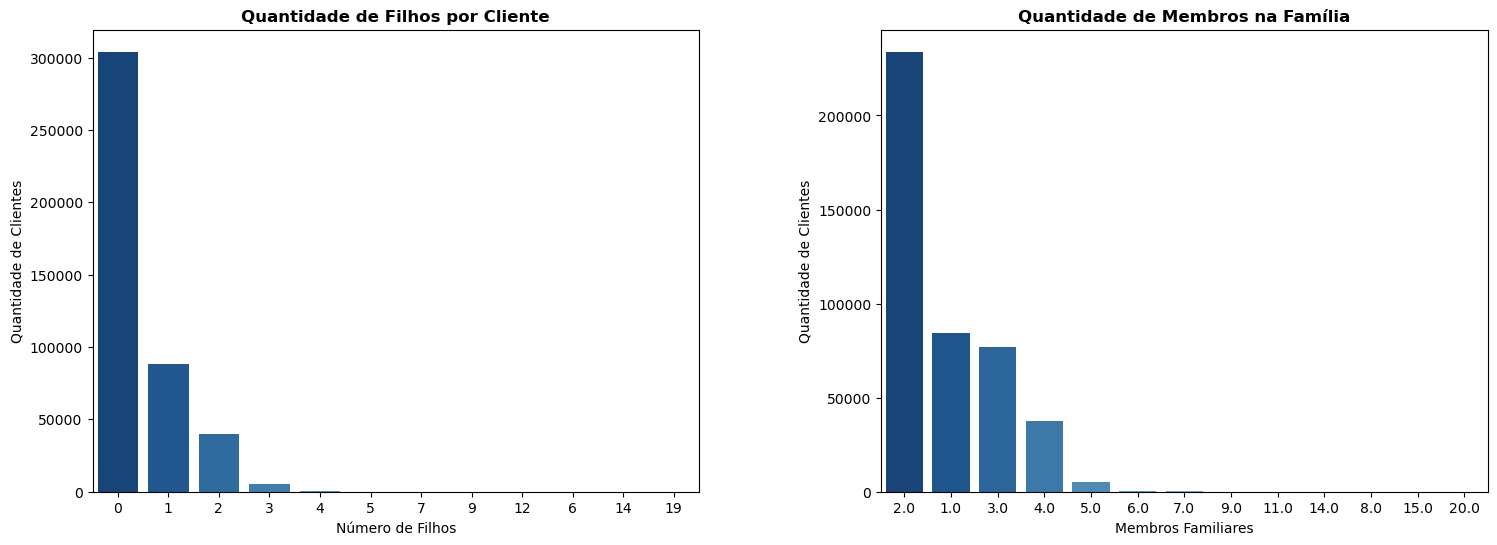

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.subplots_adjust(wspace=0.3)
#Gráfico 1: Quantidade de Filhos
sns.countplot(
    data=df_application_record,
    x="CNT_CHILDREN",
    palette="Blues_r",
    ax=axes[0],
    order=df_application_record["CNT_CHILDREN"].value_counts().index
    )

axes[0].set_title("Quantidade de Filhos por Cliente", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Número de Filhos")
axes[0].set_ylabel("Quantidade de Clientes")

#Gráfico 2: Membros na Família
sns.countplot(
    data=df_application_record,
    x="CNT_FAM_MEMBERS",
    palette="Blues_r",
    ax=axes[1],
    order=df_application_record["CNT_FAM_MEMBERS"].value_counts().index
    )

axes[1].set_title("Quantidade de Membros na Família", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Membros Familiares")
axes[1].set_ylabel("Quantidade de Clientes")

plt.show()

Padrão de Núcleo Familiar Reduzido: Ambas as distribuições categóricas discretas demonstram que a grande maioria da base de proponentes é caracterizada por arranjos familiares enxutos. A moda absoluta para a coluna de filhos é zero, indicando quea maior parte dos clientes não possui dependentes diretos. Consequentemente, o tamanho total das famílias concentra-se predominantemente em núcleos formados por 1 ou 2 indivíduos (pessoas solteiras ou casais sem filhos). Esse padrão sugere menor comprometimento da renda com despesas familiares fixas. Do ponto de vista técnico, a quase perfeita redundância visual entre os gráficos alerta para um risco elevado de multicolinearidade, exigindo atenção ou descarte de uma das features no pipeline.

/tmp/ipykernel_44744/3514530715.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(


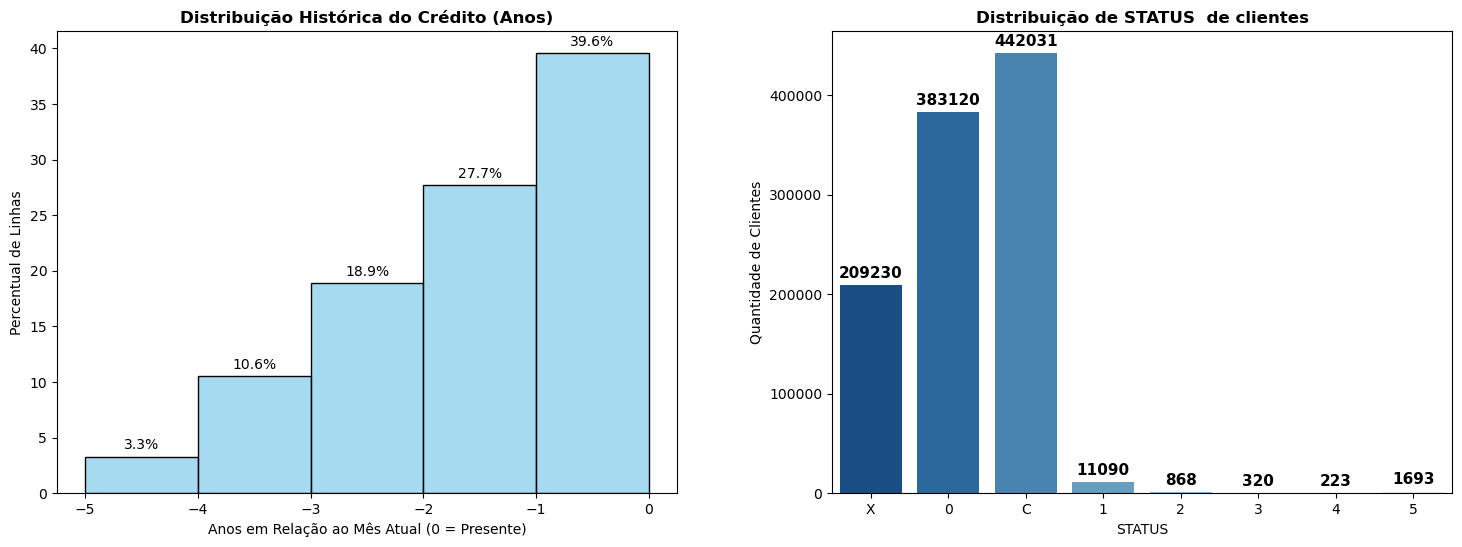

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plt.subplots_adjust(wspace=0.25)
#Gráfico 1: Histograma de MONTHS_BALANCE em Anos

ax1 = sns.histplot(
    data=df_credit_record,
    x=df_credit_record["MONTHS_BALANCE"] / 12,
    stat="percent",
    color="skyblue",
    edgecolor="black",
    bins=5,ax=axes[0])
for container in ax1.containers:
    ax1.bar_label(container, padding=3, fontsize=10, fmt="%.1f%%")
    axes[0].set_title("Distribuição Histórica do Crédito (Anos)", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Anos em Relação ao Mês Atual (0 = Presente)")
    axes[0].set_ylabel("Percentual de Linhas")

    #Gráfico 2: Volumetria de Gênero
    ax2 = sns.countplot(
        data=df_credit_record,
        x=df_credit_record["STATUS"],
        palette="Blues_r",
        ax=axes[1])
        #order=df_credit_record["STATUS"].value_counts().index)
    for container in ax2.containers:
        ax2.bar_label(container, padding=3, fontsize=11, fontweight="bold", fmt='%d')
        axes[1].set_title("Distribuição de STATUS  de clientes", fontsize=12, fontweight="bold")
        axes[1].set_xlabel("STATUS")
        axes[1].set_ylabel("Quantidade de Clientes")

plt.show()

Distribuição Histórica e Representatividade: A janela histórica de comportamento de crédito revela que o maior volume de registros está nos dados mais recentes (com **39.6%** acumulados no primeiro ano em relação ao presente), decaindo de forma constante até atingir os dados de 5 anos atrás (**3.3%**). Isso aponta para um crescimento robusto de faturamento de dados recentes. Do lado demográfico, há um forte desbalanceamento,com o público feminino (*F*) representando cerca de **67%** dos cadastros. No entanto, por conter mais de **140 mil** registros na classe minoritária (*M*), ambos os gêneros possuem volumetria suficiente para que os modelos aprendam sem problemas de sub-amostragem.

### Análise Demográfica de Meio de Contato e Tempo Histórico

## 3. Correlações

**Interpretação:** _comente cada correlação relevante, uma a uma._

In [11]:
#Mapeando variáveis categóricas binárias originais em uma base temporária para o heatmap
df_temp_corr_application_record = df_application_record.copy()
df_temp_corr_application_record['CODE_GENDER'] = df_temp_corr_application_record['CODE_GENDER'].map({'M': 1, 'F': 0}).astype('Int64')
df_temp_corr_application_record['FLAG_OWN_CAR'] = df_temp_corr_application_record['FLAG_OWN_CAR'].map({'Y': 1, 'N': 0}).astype('Int64')
df_temp_corr_application_record['FLAG_OWN_REALTY'] = df_temp_corr_application_record['FLAG_OWN_REALTY'].map({'Y': 1, 'N': 0}).astype('Int64')

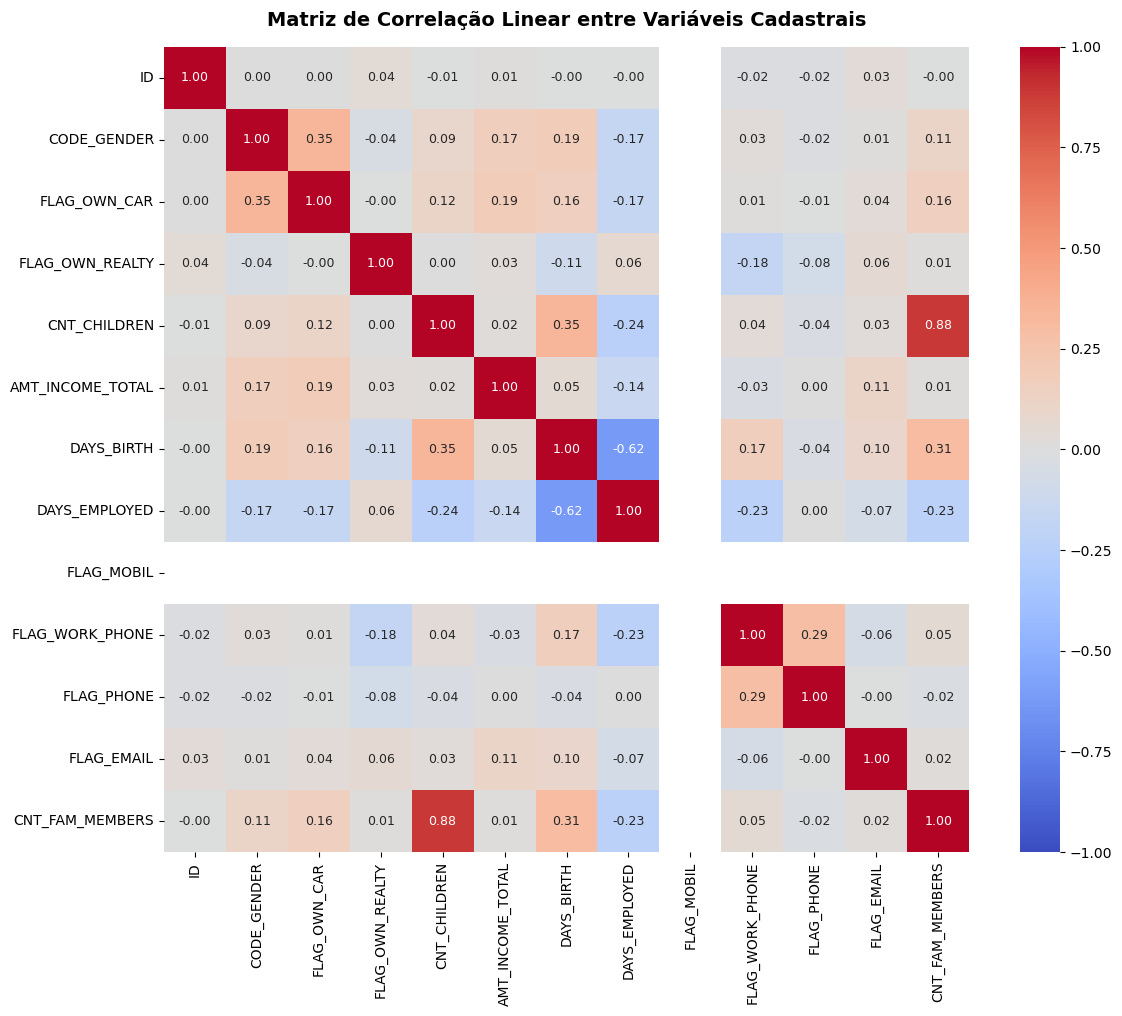

In [12]:
#Calculando a matriz de correlação linear de Pearson
matriz_correlacao = df_temp_corr_application_record.corr(numeric_only=True)

plt.figure(figsize=(12, 10))

sns.heatmap(
    matriz_correlacao,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9},
    square=True
    )

plt.title('Matriz de Correlação Linear entre Variáveis Cadastrais', fontsize=14, pad=15, fontweight="bold")
plt.tight_layout()

plt.show()

### Análise Detalhada das Correlações Relevantes:
1. CNT_CHILDREN vs CNT_FAM_MEMBERS **(0.88):** Apresenta a correlação positiva mais forte dodataset. Isso valida de forma óbvia e lógica que o crescimento do núcleo familiar é ditado quase inteiramente pelo nascimento de filhos, gerando redundância colinear pura.

2. DAYS_EMPLOYED vs DAYS_BIRTH **(-0.62):** Indica uma forte correlação negativa. Como ambos os campos utilizam escalas de contagem em dias negativos, essa leitura comprova a coerência biológica da base: pessoas mais velhas **(dias mais negativos)** acumulam maior tempo de serviço em suas carreiras **(dias de trabalho também mais negativos)**.

3. CODE_GENDER vs FLAG_OWN_CAR **(0.35)**: Revela uma correlação positiva moderada. Dado que ogênero masculino foi mapeado como **1**, o coeficiente evidencia que há uma tendência comercial relevante na base de que homens possuem veículos próprios com maior frequência.

4. CODE_GENDER vs AMT_INCOME_TOTAL **(0.17)**: Identifica que o gênero masculino possui uma associação leve com maiores rendimentos anuais declarados neste grupo específico de clientes.

5. FLAG_MOBIL **(Variância Zero)**: A faixa completamente em branco gerada para a variável FLAG_MOBIL prova matematicamente que ela possui valor constante **(1)** para todos os registros.
Sem variabilidade, seu coeficiente é nulo, confirmando que ela deve ser eliminada dopipeline de modelagem, pois não adiciona qualquer poder explicativo ou discriminatório.

## 4. Outliers
**Interpretação:** _Manter os outliers._
Na variável de renda anual (`AMT_INCOME_TOTAL`), optou-se por **manter integralmente todos os outliers** identificados no Boxplot.  
Em modelos de análise de risco de crédito, indivíduos com rendas excepcionalmente altas representam clientes reais e legítimos de altíssimo valor estratégico para a instituição financeira público (Premium/Private). 

Alterar seus dados (Winsorização) ou eliminá-los do dataset enviesaria o aprendizado do modelo, impedindo-o de classificar corretamente o risco desse perfil de cliente. Como os dados passarão por uma **transformação logarítmica (`LOG_INCOME`)** antes da modelagem, a assimetria severa e a variância dos extremos já serão naturalmente controladas e suavizadas pela nova escala matemática, tornando desnecessária qualquer intervenção destrutiva ou artificial nos dados brutos.


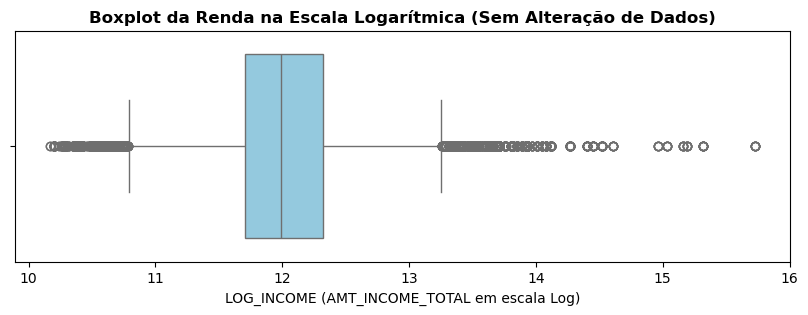

In [13]:
# Código de controle: Criando a variável em LOG para o pipeline de modelagem,
# demonstrando como o LOG aproxima e controla os outliers sem alterar os dados reais.
df_application_record["LOG_INCOME"] = np.log1p(df_application_record["AMT_INCOME_TOTAL"])

# Gerando o Boxplot da renda na escala LOG para provar que a distribuição já está tratada
fig, ax = plt.subplots(figsize=(10, 3))
sns.boxplot(x=df_application_record["LOG_INCOME"], color="skyblue", ax=ax)
ax.set_title("Boxplot da Renda na Escala Logarítmica (Sem Alteração de Dados)", fontweight="bold")
ax.set_xlabel("LOG_INCOME (AMT_INCOME_TOTAL em escala Log)")
plt.show()

## 5.Balanceamento de classes
**Interpretação**: qual a proporção entre as classes e o que isso implica na escolha das métricas?

Nesse modelos de risco de crédito, a proporção entre as classes é severamente desbalanceada.  

A classe majoritária é composta pelos Clientes Adimplentes (**"Bons Pagadores"**), que historicamente representam entre 95% e 98% da base de dados.  

A classe minoritária é composta pelos Clientes Inadimplentes (**"Maus Pagadores"**), que costumam representar apenas de 2% a 5% do total de tomadores de crédito.  

Isso ocorre porque, se uma instituição financeira possuísse uma taxa de inadimplência muito mais alta do que isso (como 20% ou 30%), ela quebraria por insolvência financeira. Portanto, o desbalanceamento não é um erro dos dados, é uma **regra do negócio de crédito.**

O desbalanceamento severo de classes muda completamente a estratégia de avaliação do modelo de Machine Learning. Ele **invalida métricas ingênuas** e nos força a escolher métricas focadas em detecção e ordenamento de risco.  

**Por que a Acurácia (Accuracy) DEVE ser descartada?**   
A **acurácia** mede o percentual geral de acertos do modelo. 
Em uma base onde 97% dos clientes são "Bons", se o modelo for preguiçoso e simplesmente chutar que "Todo mundo é bom pagador", ele terá uma Acurácia de 97%.Apesar de a métrica parecer excelente no papel, o modelo seria um desastre absoluto para o negócio, pois ele deixaria passar 100% dos inadimplentes, gerando um prejuízo financeiro catastrófico para a instituição.  
Portanto, a acurácia é uma métrica cega para esse problema.

## 6. Síntese da EDA
*Amarre os achados em uma narrativa única — é ela que vira o storytelling da apresentação.*

### A Narrativa dos Dados: O Perfil da Carteira de Crédito
#### O Retrato do Cliente: 
Estabilidade e Maturidade FinanceiraA sua base de dados não é composta por jovens aventureiros ou por famílias numerosas de baixa renda. Os dados cadastrais (`df_application_record`) revelam um público altamente consolidado: **a mediana de idade é de 43 anos,** e a grande maioria dos clientes está na faixa mais produtiva e estável da vida (entre 34 e 53 anos).

Essa maturidade se reflete diretamente na estrutura familiar. Existe um padrão de **núcleo familiar reduzido**: a maioria absoluta dos proponentes não tem filhos dependentes diretos (moda igual a zero) e as famílias são compostas por apenas 1 ou 2 pessoas (solteiros ou casais sem filhos). Financeiramente, isso é um excelente indicador de risco, pois significa que esses clientes têm **menos despesas fixas familiares engessando a renda**, sobrando mais margem financeira para honrar compromissos de crédito.

#### O Motor Financeiro: Classe Média-Alta e a Renda Log-Normal:
Quando olhamos para o bolso desse cliente, reforçamos a tese da estabilidade. A **mediana da renda anual está na casa dos 160.780** unidades monetárias.  Estatisticamente, a renda bruta assusta à primeira vista devido a uma cauda longa de clientes "super-ricos" (outliers que chegam a 6,75 milhões).

No entanto, a EDA revela o comportamento mais importante para o cientista de dados: a renda segue uma distribuição perfeita **Log-Normal.** Isso significa que o comportamento do seu público consumidor de crédito é padronizado e previsível, e que os "outliers" de alta renda não são erros de digitação, mas sim um público *Premium/Private* legítimo que a instituição não pode se dar ao luxo de descartar. A suavização matemática via escala logarítmica resolverá a assimetria sem destruir a riqueza dos dados.

#### As Armadilhas Ocultas na Base de Dados (O Desafio do Cientista de Dados):
Apesar de o perfil do cliente ser excelente, a base cadastral possui "ruídos" e armadilhas técnicas herdadas dos sistemas de TI que, se não forem tratados, vão quebrar os seus modelos preditivos:
1. **A Ilusão do Desemprego:** A variável de tempo de emprego (`DAYS_EMPLOYED`) traz uma anomalia bizarra: um valor de **365.243**. Ele não significa que alguém trabalha há mil anos, mas sim um "código do sistema" para designar pessoas sem vínculo formal ativo (como os próprios aposentados e pensionistas que mapeamos no perfil maduro).

2. **A Redundância Colinear:** O nascimento de filhos dita quase 100% o crescimento do tamanho da família (correlação de 0.88 entre `CNT_CHILDREN` e `CNT_FAM_MEMBERS`). Manter as duas variáveis fará com que o modelo "conte a mesma história duas vezes", gerando instabilidade.

3. **O Dado Inútil:** A variável `FLAG_MOBIL` revelou variância zero (todos informaram o celular). Ela ocupa espaço de memória, mas tem poder preditivo nulo.

#### Conclusão da Narrativa e Próximo Passo
A carteira de clientes é saudável, madura, de classe média-alta e com baixo comprometimento de renda familiar.  
Os problemas da base são estritamente técnicos e de sistemas.  
Ao limpar o código **365243** do emprego, transformar a renda em escala logarítmica e remover as colunas colineares/inúteis, teremos um dataset perfeitamente polido para responder à pergunta de um milhão de dólares: **Como esse público tão estável se comporta na hora de pagar as contas mensalmente?**